In [1]:
from pathlib import Path
import json
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

PROJECT_ROOT = Path.cwd().resolve().parent
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
BASELINE_DIR = OUTPUTS_DIR / 'baseline_inputs'
FRONTIER_DIR = OUTPUTS_DIR / 'frontiers'
TABLES_DIR = OUTPUTS_DIR / 'tables'

with (OUTPUTS_DIR / 'metadata.json').open(encoding='utf-8') as handle:
    metadata = json.load(handle)

with (FRONTIER_DIR / 'frontiers.pkl').open('rb') as handle:
    frontier_bundle = pickle.load(handle)

mean_returns = pd.read_csv(BASELINE_DIR / 'mean_returns.csv')
covariance = pd.read_csv(BASELINE_DIR / 'covariance_matrix.csv', index_col=0)
baseline_returns = pd.read_csv(BASELINE_DIR / 'baseline_returns.csv', parse_dates=['Date'])
windows = pd.read_csv(BASELINE_DIR / 'windows.csv', parse_dates=['requested_start_date', 'start_date', 'end_date'])

frontier_tables = {
    name: pd.read_csv(FRONTIER_DIR / f'frontier_{name}.csv')
    for name in ['unrestricted_short', 'short_limit_25pct', 'no_short', 'min_2pct_each']
}

weight_tables = {
    name: pd.read_csv(TABLES_DIR / f'weights_{name}.csv')
    for name in ['unrestricted_short', 'short_limit_25pct', 'no_short', 'min_2pct_each']
}


In [2]:
summary = pd.DataFrame([
    {
        'scenario_name': name,
        'points': len(frontier_tables[name]),
        'min_risk': frontier_tables[name]['portfolio_risk'].min(),
        'max_risk': frontier_tables[name]['portfolio_risk'].max(),
        'max_return': frontier_tables[name]['portfolio_return'].max(),
    }
    for name in frontier_tables
]).sort_values('scenario_name')

print('Baseline window:', metadata['baseline_window']['start_date'], '->', metadata['baseline_window']['end_date'])
print('Baseline observations:', metadata['baseline_window']['n_observations'])
print('Tickers:', len(mean_returns))
print('Covariance matrix shape:', covariance.shape)
print('Rolling windows prepared:', len(windows))
summary

Baseline window: 2024-12-30 -> 2025-12-30
Baseline observations: 255
Tickers: 30
Covariance matrix shape: (30, 30)
Rolling windows prepared: 10


,scenario_name,points,min_risk,max_risk,max_return
3,min_2pct_each,80,0.012240,0.013263,0.000518
2,no_short,80,0.010051,0.017784,0.001554
1,short_limit_25pct,80,0.008361,0.151961,0.014505
0,unrestricted_short,80,0.008361,0.048036,0.014505


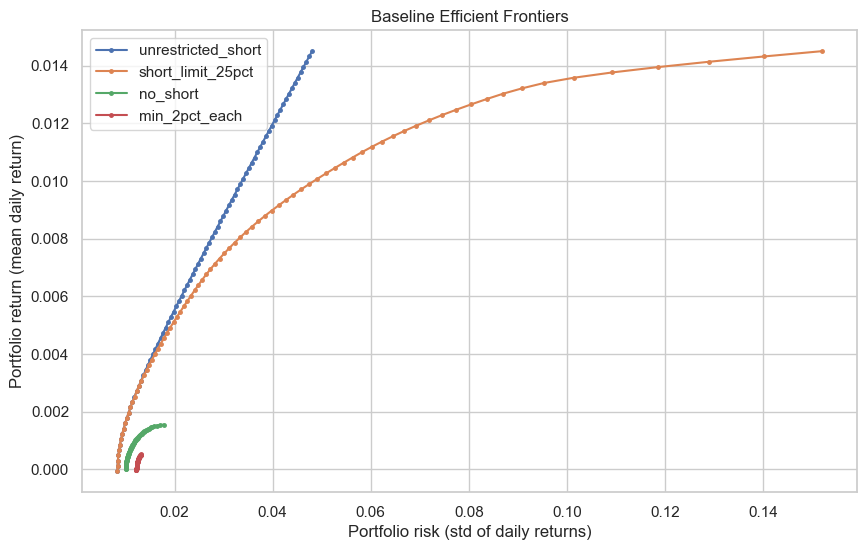

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
for scenario_name, frontier in frontier_tables.items():
    ax.plot(
        frontier['portfolio_risk'],
        frontier['portfolio_return'],
        marker='o',
        markersize=2.5,
        linewidth=1.5,
        label=scenario_name,
    )

ax.set_title('Baseline Efficient Frontiers')
ax.set_xlabel('Portfolio risk (std of daily returns)')
ax.set_ylabel('Portfolio return (mean daily return)')
ax.legend()
plt.show()

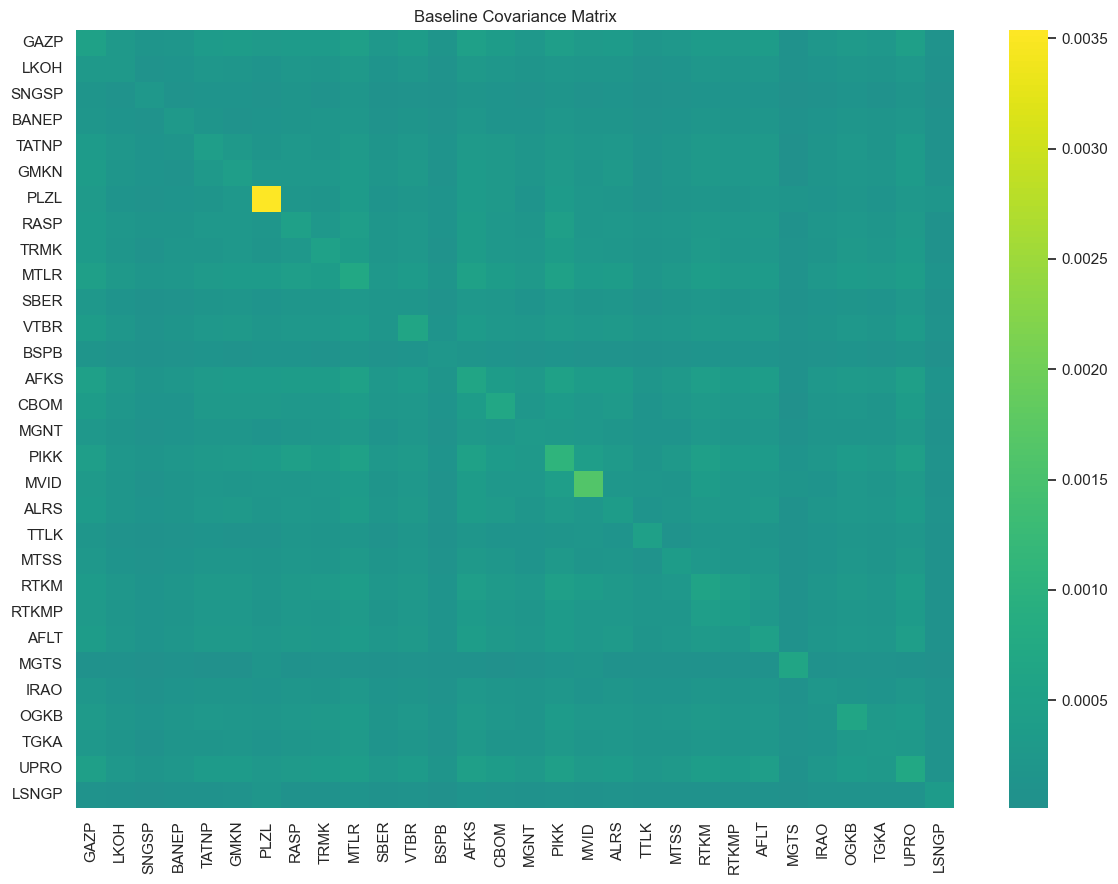

In [4]:
plt.figure(figsize=(12, 9))
sns.heatmap(covariance, cmap='viridis', center=0)
plt.title('Baseline Covariance Matrix')
plt.tight_layout()
plt.show()

/var/folders/52/3z6847g54nj0nypztd8phrb40000gn/T/ipykernel_31586/3887469215.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_returns_sorted, x='ticker', y='mean_return', palette='crest')


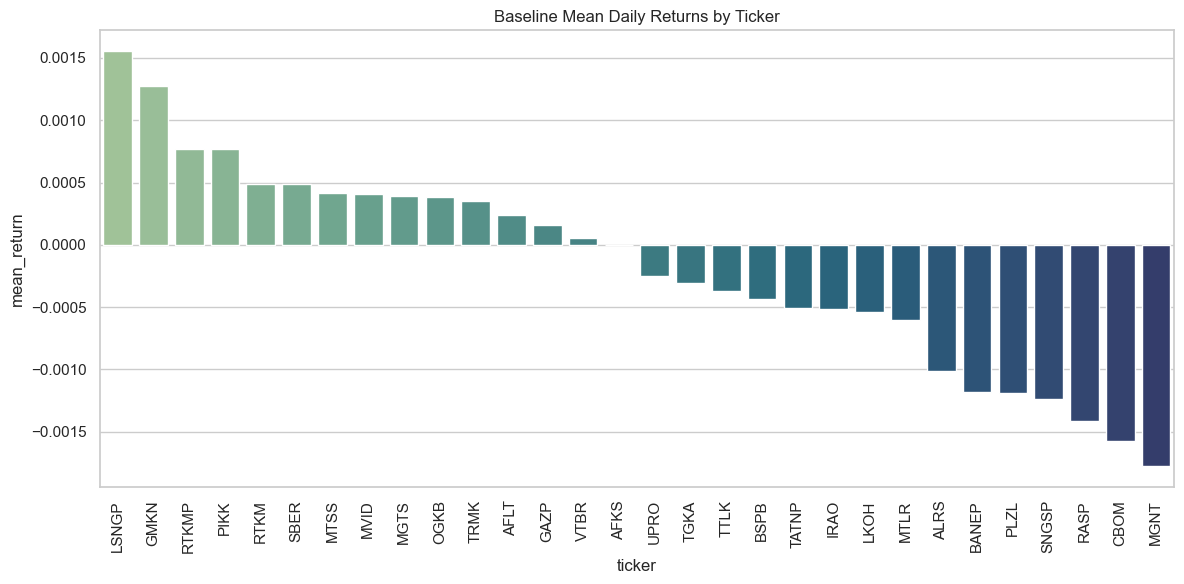

In [5]:
mean_returns_sorted = mean_returns.sort_values('mean_return', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=mean_returns_sorted, x='ticker', y='mean_return', palette='crest')
plt.title('Baseline Mean Daily Returns by Ticker')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [6]:
gmv_summary = pd.DataFrame([
    {
        'scenario_name': scenario_name,
        'gmv_return': payload['gmv']['portfolio_return'],
        'gmv_risk': payload['gmv']['portfolio_risk'],
    }
    for scenario_name, payload in frontier_bundle.items()
]).sort_values('scenario_name')

highest_mean = mean_returns_sorted.iloc[0]
lowest_mean = mean_returns_sorted.iloc[-1]

print('GMV summary:')
display(gmv_summary)
print()
print('Highest baseline mean return ticker:', highest_mean['ticker'], f"({highest_mean['mean_return']:.6f})")
print('Lowest baseline mean return ticker:', lowest_mean['ticker'], f"({lowest_mean['mean_return']:.6f})")
print('Unrestricted frontier exported points:', len(frontier_tables['unrestricted_short']))
print('No-short frontier exported points:', len(frontier_tables['no_short']))

GMV summary:


,scenario_name,gmv_return,gmv_risk
3,min_2pct_each,-0.000025,0.012240
2,no_short,0.000011,0.010051
1,short_limit_25pct,-0.000062,0.008361
0,unrestricted_short,-0.000062,0.008361



Highest baseline mean return ticker: LSNGP (0.001554)
Lowest baseline mean return ticker: MGNT (-0.001777)
Unrestricted frontier exported points: 80
No-short frontier exported points: 80
